# Classification Model Evaluation

Evaluates `OrdinalPairClassifier` on the held-out test split. Covers accuracy, MAE, confusion matrices, error distributions, per-bucket breakdowns, and qualitative examples.

In [1]:
import sys
from pathlib import Path

# Add ChordEdit root so 'models.classification.*' imports work
ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader

from models.classification.model import (
    OrdinalPairClassifier,
    decode_ordinal,
    mae_buckets,
)
from models.classification.classify import PairDataset, collate, eval_loader

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load Data

In [11]:
DATA_DIR = Path("data")
WEIGHTS_DIR = Path("weights")

train_df = pd.read_parquet(DATA_DIR / "train.parquet.gz")
val_df   = pd.read_parquet(DATA_DIR / "val.parquet.gz")
test_df  = pd.read_parquet(DATA_DIR / "test.parquet.gz")

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
print(f"t_start buckets: {sorted(train_df['t_start'].unique())}")
print(f"t_end   buckets: {sorted(train_df['t_end'].unique())}")
test_df

train: 448  val: 56  test: 56
t_start buckets: [np.float64(0.0), np.float64(0.3), np.float64(0.6), np.float64(0.9), np.float64(1.0)]
t_end   buckets: [np.float64(0.0), np.float64(0.3), np.float64(0.6), np.float64(0.9), np.float64(1.0)]


,sample_id,t_start,t_end,id,source_prompt,target_prompt,t_start_idx,t_end_idx
0,111000000008,0.0,0.0,111000000008,a [monkey] wearing colorful goggles and a colo...,a [man] wearing colorful goggles and a colorfu...,0,0
1,112000000003,0.3,0.0,112000000003,a girl with black hair and a white shirt is ho...,a girl with black hair and a white shirt is ho...,1,0
2,112000000004,0.0,0.0,112000000004,a cartoon girl sitting on a [backpack],a cartoon girl sitting on a [rock],0,0
3,114000000004,0.0,0.0,114000000004,a blue pyramid with a reflection of [mountains...,a blue pyramid with a reflection of [ship] in ...,0,0
4,121000000003,0.3,0.3,121000000003,a white [bulldog] is walking on the grass,a white [rat] is walking on the grass,1,1
5,123000000002,0.0,0.0,123000000002,a [book] on the table,a [painting] on the table,0,0
6,123000000004,0.0,0.0,123000000004,a blue glass [pendant] on a black cord,a blue glass [purse] on a black cord,0,0
7,211000000007,0.0,0.0,211000000007,a digital art of charcoal grey little squirrel...,a digital art of charcoal grey little squirrel...,0,0
8,213000000002,0.0,0.0,213000000002,paper art,paper art [and kids],0,0
9,213000000005,0.0,0.0,213000000005,a large brown teddy bear sitting on a white couch,a large brown teddy bear [and a girl] sitting ...,0,0


### 2. Load Model

In [3]:
# Pick the most recently saved weights
weight_files = sorted(WEIGHTS_DIR.glob("classifier_weights_*.pt"))
assert weight_files, "No weight files found in weights/"
latest_weights = weight_files[-1]
print(f"Loading: {latest_weights.name}")

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
buckets_start = torch.tensor(sorted(all_df["t_start"].unique()), dtype=torch.float)
buckets_end   = torch.tensor(sorted(all_df["t_end"].unique()),   dtype=torch.float)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OrdinalPairClassifier(
    buckets1=buckets_start, buckets2=buckets_end, freeze_encoder=True
).to(DEVICE)
model.load_state_dict(torch.load(latest_weights, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Device: {DEVICE}")

Loading: classifier_weights_20260617_113810.pt


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13259.67it/s]


Device: cuda


### 3. Run Inference on All Splits

In [4]:
BATCH_SIZE = 32

def predict_split(df: pd.DataFrame) -> dict:
    """Return dict with pred/true arrays for both heads."""
    loader = DataLoader(PairDataset(df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    p1_list, p2_list, l1_list, l2_list = [], [], [], []
    with torch.no_grad():
        for srcs, tgts, l1, l2 in loader:
            l1, l2 = l1.to(DEVICE), l2.to(DEVICE)
            out1, out2 = model(srcs, tgts)
            p1_list.append(decode_ordinal(out1).cpu())
            p2_list.append(decode_ordinal(out2).cpu())
            l1_list.append(l1.cpu())
            l2_list.append(l2.cpu())
    return {
        "pred_start": torch.cat(p1_list).numpy(),
        "pred_end":   torch.cat(p2_list).numpy(),
        "true_start": torch.cat(l1_list).numpy(),
        "true_end":   torch.cat(l2_list).numpy(),
    }

results = {
    "train": predict_split(train_df),
    "val":   predict_split(val_df),
    "test":  predict_split(test_df),
}
print("Inference complete.")

Inference complete.


### 4. Metrics Summary

In [5]:
def compute_metrics(r: dict) -> dict:
    p1 = torch.tensor(r["pred_start"])
    p2 = torch.tensor(r["pred_end"])
    t1 = torch.tensor(r["true_start"])
    t2 = torch.tensor(r["true_end"])
    return {
        "mae_start":  mae_buckets(p1, t1).item(),
        "mae_end":    mae_buckets(p2, t2).item(),
        "acc_start":  (p1 == t1).float().mean().item(),
        "acc_end":    (p2 == t2).float().mean().item(),
        "acc_both":   ((p1 == t1) & (p2 == t2)).float().mean().item(),
    }

metrics_df = pd.DataFrame(
    {split: compute_metrics(r) for split, r in results.items()}
).T.rename(columns={
    "mae_start": "MAE t_start",
    "mae_end":   "MAE t_end",
    "acc_start": "Acc t_start",
    "acc_end":   "Acc t_end",
    "acc_both":  "Joint Acc",
})
metrics_df.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=0)

,MAE t_start,MAE t_end,Acc t_start,Acc t_end,Joint Acc
train,0.000,0.000,1.000,1.000,1.000
val,0.625,0.179,0.482,0.875,0.446
test,0.786,0.179,0.464,0.857,0.446


### 5. Metrics Across Splits (Bar Chart)

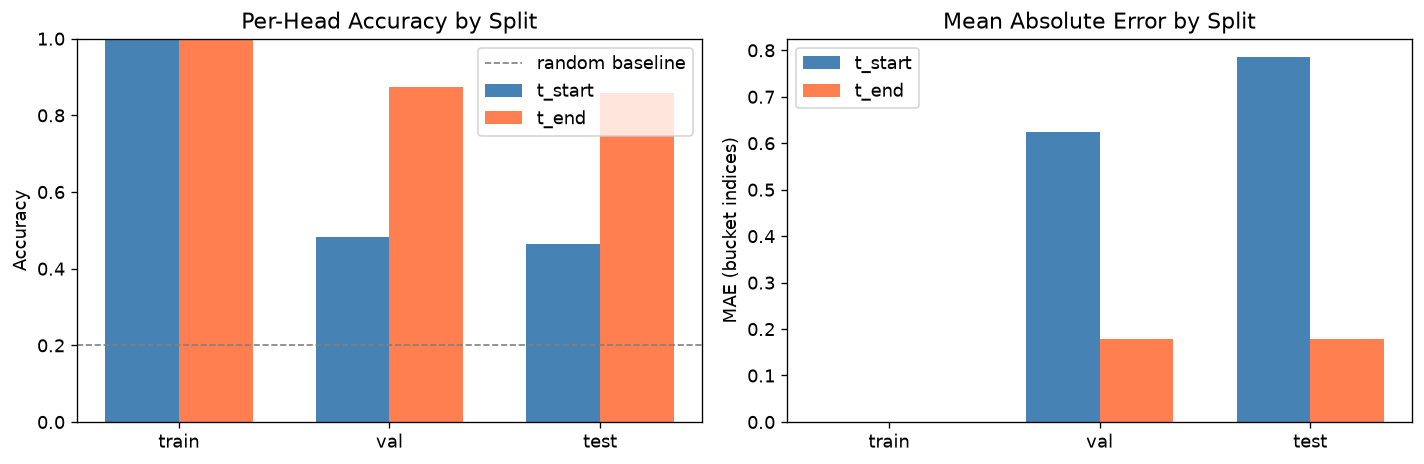

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
splits = ["train", "val", "test"]
x = np.arange(len(splits))
width = 0.35

# Accuracy panel
ax = axes[0]
m = {s: compute_metrics(results[s]) for s in splits}
ax.bar(x - width/2, [m[s]["acc_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["acc_end"]   for s in splits], width, label="t_end",   color="coral")
ax.axhline(1/5, color="gray", linestyle="--", linewidth=1, label="random baseline")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Accuracy"); ax.set_title("Per-Head Accuracy by Split")
ax.set_ylim(0, 1); ax.legend()

# MAE panel
ax = axes[1]
ax.bar(x - width/2, [m[s]["mae_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["mae_end"]   for s in splits], width, label="t_end",   color="coral")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("MAE (bucket indices)"); ax.set_title("Mean Absolute Error by Split")
ax.legend()

plt.tight_layout()
plt.savefig("outputs/metrics_by_split.png", bbox_inches="tight")
plt.show()

### 6. Confusion Matrices (Test Set)

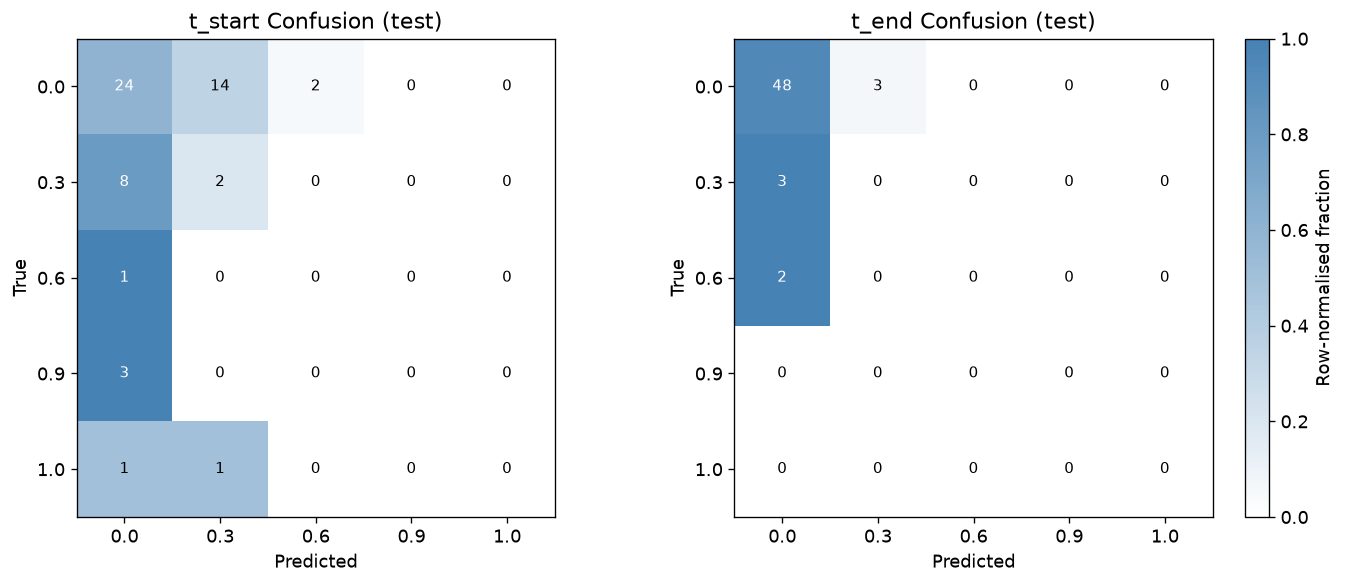

In [8]:
from sklearn.metrics import confusion_matrix

BUCKET_LABELS = ["0.0", "0.3", "0.6", "0.9", "1.0"]
cmap = LinearSegmentedColormap.from_list("wb", ["white", "steelblue"])

def plot_confusion(ax, true, pred, title):
    cm = confusion_matrix(true, pred, labels=list(range(5)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                    fontsize=9, color="white" if cm_norm[i,j] > 0.5 else "black")
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(BUCKET_LABELS); ax.set_yticklabels(BUCKET_LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    return im

r = results["test"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = plot_confusion(axes[0], r["true_start"], r["pred_start"], "t_start Confusion (test)")
im2 = plot_confusion(axes[1], r["true_end"],   r["pred_end"],   "t_end Confusion (test)")
fig.colorbar(im2, ax=axes[1], label="Row-normalised fraction")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices.png", bbox_inches="tight")
plt.show()

### 7. Error Distribution

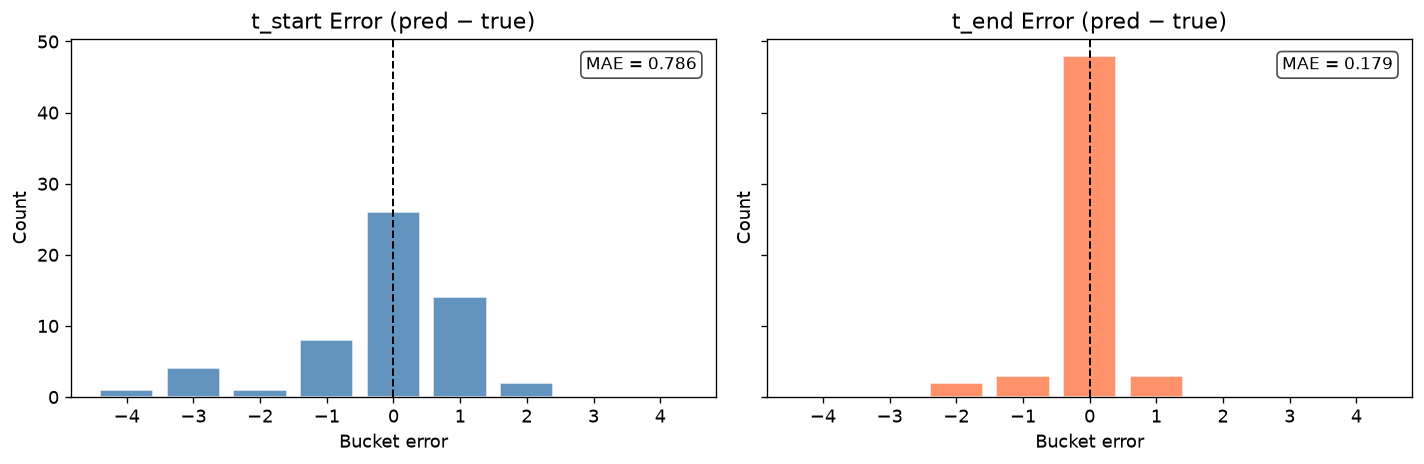

In [9]:
r = results["test"]
err_start = r["pred_start"] - r["true_start"]
err_end   = r["pred_end"]   - r["true_end"]

bins = np.arange(-4.5, 5.5, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, err, title, color in [
    (axes[0], err_start, "t_start Error (pred − true)", "steelblue"),
    (axes[1], err_end,   "t_end Error (pred − true)",   "coral"),
]:
    counts, edges = np.histogram(err, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, counts, width=0.8, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Bucket error")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    mae_val = np.abs(err).mean()
    ax.text(0.97, 0.95, f"MAE = {mae_val:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.savefig("outputs/error_distribution.png", bbox_inches="tight")
plt.show()

### 8. Predicted vs. True Class Distributions

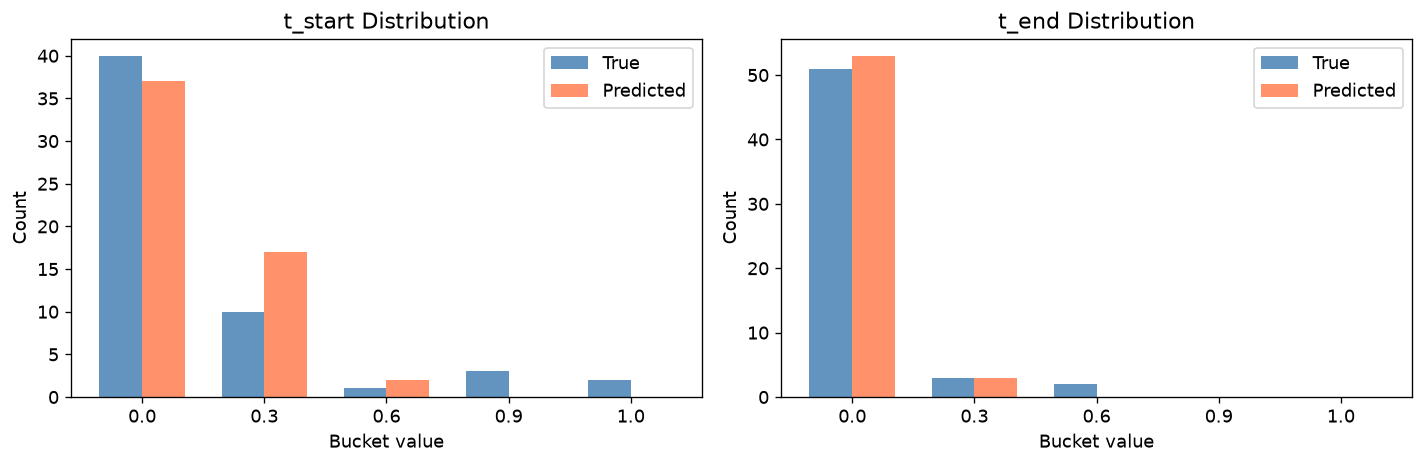

In [10]:
r = results["test"]
bucket_vals = np.array([0.0, 0.3, 0.6, 0.9, 1.0])
x = np.arange(5)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title in [
    (axes[0], "pred_start", "true_start", "t_start Distribution"),
    (axes[1], "pred_end",   "true_end",   "t_end Distribution"),
]:
    true_counts = np.bincount(r[true_key], minlength=5)
    pred_counts = np.bincount(r[pred_key], minlength=5)
    ax.bar(x - width/2, true_counts, width, label="True",      color="steelblue", alpha=0.85)
    ax.bar(x + width/2, pred_counts, width, label="Predicted", color="coral",     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(BUCKET_LABELS)
    ax.set_xlabel("Bucket value"); ax.set_ylabel("Count")
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig("outputs/class_distribution.png", bbox_inches="tight")
plt.show()

### 9. Per-Bucket Accuracy

In [ ]:
r = results["test"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title, color in [
    (axes[0], "pred_start", "true_start", "Per-Bucket Accuracy: t_start", "steelblue"),
    (axes[1], "pred_end",   "true_end",   "Per-Bucket Accuracy: t_end",   "coral"),
]:
    accs, counts = [], []
    for bucket in range(5):
        mask = r[true_key] == bucket
        n = mask.sum()
        acc = (r[pred_key][mask] == bucket).mean() if n > 0 else float("nan")
        accs.append(acc)
        counts.append(n)
    bars = ax.bar(range(5), accs, color=color, alpha=0.85, edgecolor="white")
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"n={n}", ha="center", va="bottom", fontsize=9)
    ax.axhline(1/5, color="gray", linestyle="--", linewidth=1, label="random baseline")
    ax.set_xticks(range(5)); ax.set_xticklabels(BUCKET_LABELS)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.15); ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig("outputs/per_bucket_accuracy.png", bbox_inches="tight")
plt.show()

### 10. Scatter: Predicted vs. True Bucket Indices

In [ ]:
r = results["test"]
jitter = 0.12
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pred_key, true_key, title, color in [
    (axes[0], "pred_start", "true_start", "t_start", "steelblue"),
    (axes[1], "pred_end",   "true_end",   "t_end",   "coral"),
]:
    jx = r[true_key] + rng.uniform(-jitter, jitter, len(r[true_key]))
    jy = r[pred_key] + rng.uniform(-jitter, jitter, len(r[pred_key]))
    ax.scatter(jx, jy, alpha=0.5, s=30, color=color, edgecolors="none")
    ax.plot([0, 4], [0, 4], "k--", linewidth=1, label="perfect")
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(BUCKET_LABELS); ax.set_yticklabels(BUCKET_LABELS)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Predicted bucket")
    ax.set_title(f"{title} — Scatter")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/scatter_pred_vs_true.png", bbox_inches="tight")
plt.show()

## 11. Ordinal Threshold Probabilities (Head Internals)

In [ ]:
# Show the average sigmoid(logit) per threshold, grouped by true bucket
loader = DataLoader(PairDataset(test_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

all_logits1, all_logits2, all_l1, all_l2 = [], [], [], []
with torch.no_grad():
    for srcs, tgts, l1, l2 in loader:
        out1, out2 = model(srcs, tgts)
        all_logits1.append(out1.cpu())
        all_logits2.append(out2.cpu())
        all_l1.append(l1)
        all_l2.append(l2)

logits1 = torch.cat(all_logits1).numpy()   # (N, 4)
logits2 = torch.cat(all_logits2).numpy()
true1   = torch.cat(all_l1).numpy()
true2   = torch.cat(all_l2).numpy()

def sigmoid(x): return 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharey=True)
threshold_labels = ["P(≥0.3)", "P(≥0.6)", "P(≥0.9)", "P(≥1.0)"]

for head_idx, (logits, true, head_name) in enumerate(
    [(logits1, true1, "t_start"), (logits2, true2, "t_end")]
):
    for bucket in range(5):
        ax = axes[head_idx][bucket]
        mask = true == bucket
        if mask.sum() == 0:
            ax.set_visible(False)
            continue
        probs = sigmoid(logits[mask]).mean(axis=0)  # (4,)
        colors = ["steelblue" if p > 0.5 else "lightcoral" for p in probs]
        ax.bar(range(4), probs, color=colors, edgecolor="white")
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.set_xticks(range(4)); ax.set_xticklabels(threshold_labels, fontsize=7, rotation=30, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(f"{head_name}\ntrue={BUCKET_LABELS[bucket]} (n={mask.sum()})", fontsize=9)
        if bucket == 0:
            ax.set_ylabel("Mean P(threshold exceeded)")

plt.suptitle("Ordinal Threshold Probabilities by True Bucket", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/threshold_probs.png", bbox_inches="tight")
plt.show()

## 12. Qualitative Examples

In [ ]:
r = results["test"]
bucket_vals = np.array([0.0, 0.3, 0.6, 0.9, 1.0])

test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy["pred_start"] = bucket_vals[r["pred_start"]]
test_df_copy["pred_end"]   = bucket_vals[r["pred_end"]]
test_df_copy["err_start"]  = abs(r["pred_start"] - r["true_start"])
test_df_copy["err_end"]    = abs(r["pred_end"]   - r["true_end"])
test_df_copy["max_err"]    = test_df_copy[["err_start", "err_end"]].max(axis=1)

# Show: 4 correct predictions and 4 worst mistakes
correct = test_df_copy[(test_df_copy.err_start == 0) & (test_df_copy.err_end == 0)].head(4)
wrong   = test_df_copy.sort_values("max_err", ascending=False).head(4)

def show_examples(df, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    for _, row in df.iterrows():
        print(f"  source: {row['source_prompt'][:80]}")
        print(f"  target: {row['target_prompt'][:80]}")
        print(f"  t_start  true={row['t_start']:.1f}  pred={row['pred_start']:.1f}")
        print(f"  t_end    true={row['t_end']:.1f}  pred={row['pred_end']:.1f}")
        print()

show_examples(correct, "Correct predictions")
show_examples(wrong,   "Largest errors")

## 13. Summary

In [ ]:
m = compute_metrics(results["test"])
print("Test-set summary")
print(f"  MAE  t_start: {m['mae_start']:.3f}   t_end: {m['mae_end']:.3f}")
print(f"  Acc  t_start: {m['acc_start']:.1%}  t_end: {m['acc_end']:.1%}")
print(f"  Joint accuracy (both correct): {m['acc_both']:.1%}")
print(f"  Random-chance accuracy: {1/5:.1%}")